## Bước 10 (Đã sửa lỗi UnpicklingError): Trực quan hóa một lần chạy cụ thể

- Phiên bản này khắc phục lỗi **`UnpicklingError`** xảy ra khi PyTorch không thể giải nén checkpoint `.pth` do thay đổi cách lưu trong các bản PyTorch mới.
- Cụ thể: thêm tham số **`weights_only=False`** khi gọi `torch.load()` để cho phép đọc các checkpoint chứa nhiều loại dữ liệu (model state, optimizer, history, v.v.).
- Tính năng chính:
  1. **Tự động phát hiện checkpoint mới nhất** dựa trên số epoch trong tên file (`epoch_NUMBER.pth`).
  2. **Tự động fallback** sang checkpoint nếu `training_history.json` chưa được tạo.
  3. Hiển thị trực quan 4 biểu đồ theo dõi quá trình training:
     - **Loss (MSE)**  
     - **RMSE (Root Mean Squared Error)**  
     - **MAE (Mean Absolute Error)**  
     - **Pearson Correlation (r)**  
- Giúp người dùng có thể xem nhanh tiến trình huấn luyện ngay cả khi training bị ngắt giữa chừng.


In [ ]:
import os
import json
import math
from datetime import datetime

import numpy as np
import pandas as pd
import torch

# Thư viện cho đánh giá và trực quan hóa
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import glob
import re
import os
import json
import torch

# =============================================================================
# 1. CẤU HÌNH: CHỈ CẦN CHỈNH SỬA Ở ĐÂY
# =============================================================================
BASE_CHECKPOINT_DIR = "/content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced"
TARGET_RUN_FOLDER = "20251024_051938"  # <--- CHỈNH SỬA DÒNG NÀY
# =============================================================================

# --- 2. Xây dựng đường dẫn và kiểm tra ---
plot_run_dir = os.path.join(BASE_CHECKPOINT_DIR, TARGET_RUN_FOLDER)
history = None

if not os.path.isdir(plot_run_dir):
    print(f"❌ LỖI: Không tìm thấy thư mục tại: '{plot_run_dir}'")
else:
    print(f"Đang phân tích thư mục: {plot_run_dir}")
    history_path = os.path.join(plot_run_dir, "training_history.json")

    if os.path.exists(history_path):
        print(f"Tìm thấy file history cuối cùng. Đang tải từ: {history_path}")
        with open(history_path, 'r') as f:
            history = json.load(f)
    else:
        print("Không tìm thấy file history.json. Đang thử tải từ checkpoint mới nhất...")
        checkpoint_files = glob.glob(os.path.join(plot_run_dir, "epoch_*.pth"))
        if checkpoint_files:
            latest_epoch = -1
            latest_checkpoint = None
            for f_path in checkpoint_files:
                filename = os.path.basename(f_path)
                match = re.search(r'epoch_(\d+)\.pth', filename)
                if match:
                    epoch_num = int(match.group(1))
                    if epoch_num > latest_epoch:
                        latest_epoch = epoch_num
                        latest_checkpoint = f_path
            if latest_checkpoint:
                print(f"Đang tải history từ checkpoint mới nhất (epoch {latest_epoch}): {os.path.basename(latest_checkpoint)}")
                # === SỬA LỖI: Thêm tham số weights_only=False ===
                checkpoint = torch.load(latest_checkpoint, map_location='cpu', weights_only=False)  # <--- THAY ĐỔI Ở ĐÂY
                # ================================================
                if 'history' in checkpoint:
                    history = checkpoint['history']
                else:
                    print("Lỗi: Checkpoint không chứa 'history'.")
            else:
                print("Lỗi: Không tìm thấy file checkpoint nào có định dạng 'epoch_NUMBER.pth'.")
        else:
            print("Lỗi: Không tìm thấy file checkpoint nào trong thư mục.")

Đang phân tích thư mục: /content/drive/MyDrive/era5_vn_min/processed/checkpoints_advanced/20251024_051938
Không tìm thấy file history.json. Đang thử tải từ checkpoint mới nhất...
Đang tải history từ checkpoint mới nhất (epoch 22): epoch_22.pth



Tìm thấy dữ liệu của 22 epoch. Bắt đầu vẽ biểu đồ...


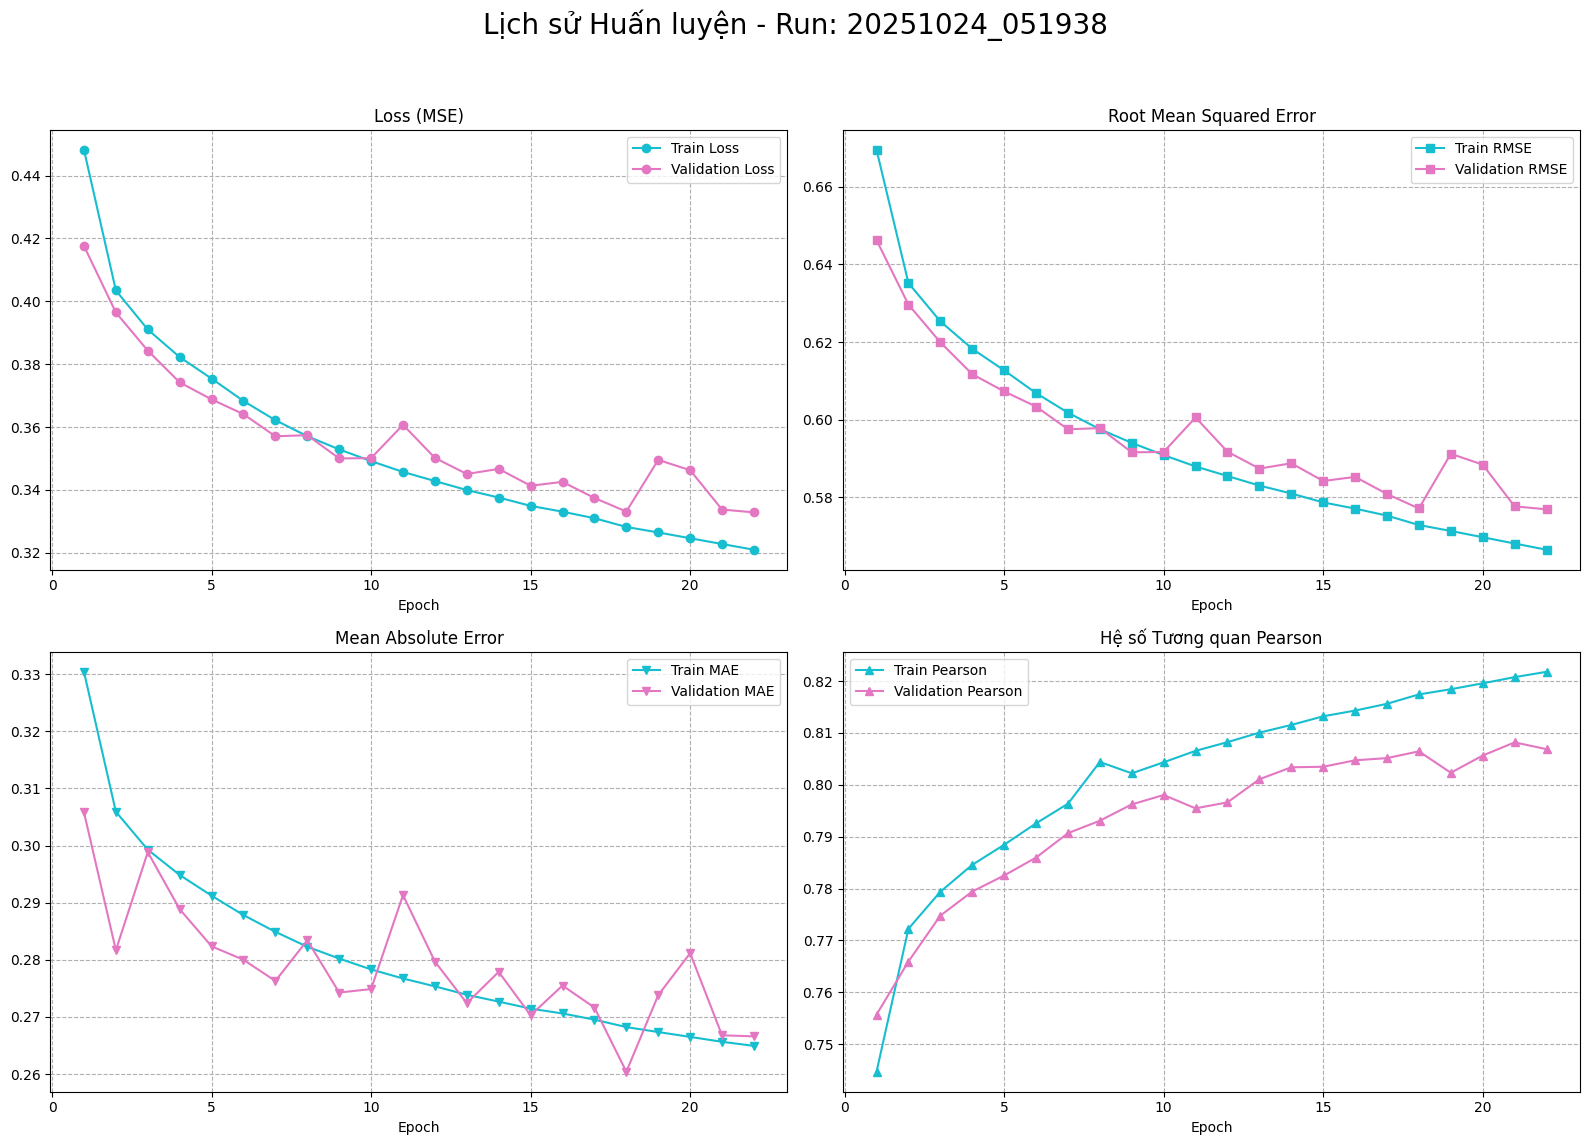

In [ ]:
import matplotlib.pyplot as plt

# --- 3. Vẽ Biểu đồ nếu History được tải thành công ---
if history:
    epochs_ran = len(history['train_loss'])
    print(f"\nTìm thấy dữ liệu của {epochs_ran} epoch. Bắt đầu vẽ biểu đồ...")
    epochs = range(1, epochs_ran + 1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Lịch sử Huấn luyện - Run: {TARGET_RUN_FOLDER}', fontsize=20)

    # --- Loss ---
    axes[0, 0].plot(epochs, history['train_loss'], color='#17becf', marker='o', linestyle='-', label='Train Loss')
    axes[0, 0].plot(epochs, history['val_loss'], color='#e377c2', marker='o', linestyle='-', label='Validation Loss')
    axes[0, 0].set_title('Loss (MSE)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--')
    axes[0, 0].set_xlabel('Epoch')

    # --- RMSE ---
    axes[0, 1].plot(epochs, history['train_rmse'], color='#17becf', marker='s', linestyle='-', label='Train RMSE')
    axes[0, 1].plot(epochs, history['val_rmse'], color='#e377c2', marker='s', linestyle='-', label='Validation RMSE')
    axes[0, 1].set_title('Root Mean Squared Error')
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--')
    axes[0, 1].set_xlabel('Epoch')

    # --- MAE ---
    axes[1, 0].plot(epochs, history['train_mae'], color='#17becf', marker='v', linestyle='-', label='Train MAE')
    axes[1, 0].plot(epochs, history['val_mae'], color='#e377c2', marker='v', linestyle='-', label='Validation MAE')
    axes[1, 0].set_title('Mean Absolute Error')
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--')
    axes[1, 0].set_xlabel('Epoch')

    # --- Pearson ---
    axes[1, 1].plot(epochs, history['train_pearson'], color='#17becf', marker='^', linestyle='-', label='Train Pearson')
    axes[1, 1].plot(epochs, history['val_pearson'], color='#e377c2', marker='^', linestyle='-', label='Validation Pearson')
    axes[1, 1].set_title('Hệ số Tương quan Pearson')
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--')
    axes[1, 1].set_xlabel('Epoch')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("\nKhông thể vẽ biểu đồ do không tải được dữ liệu history.")
